In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score


In [3]:
df = pd.read_csv("exoplanet_clean_40k.csv")
df.head()


,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,...,rowupdate,pl_pubdate,releasedate,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,1,...,9/19/2023,2023-08,9/19/2023,2,1,2,0,0,0,0
1,2,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,5/14/2014,2008-01,5/14/2014,2,1,2,0,0,0,0
2,3,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,7/23/2014,2011-08,7/23/2014,2,1,2,0,0,0,0
3,4,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,0,...,4/25/2018,2009-10,5/14/2014,0,1,1,0,0,0,0
4,5,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,1,...,9/4/2018,2017-03,9/6/2018,0,1,1,0,0,0,0


In [4]:
df = df[[
    'pl_rade',      # planet radius
    'pl_bmasse',    # planet mass
    'pl_orbper',    # orbital period
    'pl_eqt',       # equilibrium temp
    'st_teff',      # star temperature
    'st_lum'        # star luminosity
]]


In [5]:
df = df.dropna()

df = df[df['pl_eqt'] < 1000]  # remove extreme outliers

df.describe()


,pl_rade,pl_bmasse,pl_orbper,pl_eqt,st_teff,st_lum
count,111.000000,111.000000,1.110000e+02,111.000000,111.000000,111.000000
mean,4.268913,103.828993,3.621644e+06,687.478739,4749.570000,-0.710763
std,3.638239,328.297163,3.815615e+07,180.265156,949.688182,0.792496
min,0.750000,0.550000,9.263237e-01,124.700000,2949.000000,-2.552840
25%,1.990000,4.490000,3.797684e+00,559.000000,3803.000000,-1.206355
50%,2.733000,10.400000,9.489712e+00,693.000000,4803.000000,-0.577410
75%,4.211200,31.521500,2.130936e+01,831.550000,5543.500000,-0.121210
max,13.058463,2302.899000,4.020000e+08,981.200000,6203.000000,0.440910


In [10]:
df['habitable'] = ((df['pl_eqt'] >= 273.15) & (df['pl_eqt'] <= 373.15)).astype(int)

X = df.drop("habitable", axis=1)
y = df["habitable"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [12]:
lr = LogisticRegression()
lr.fit(X_train, y_train)


LogisticRegression()

In [13]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)


RandomForestClassifier()

In [14]:
print("Random Forest Report")
print(classification_report(y_test, rf.predict(X_test)))

print("ROC AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))


Random Forest Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23

ROC AUC: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


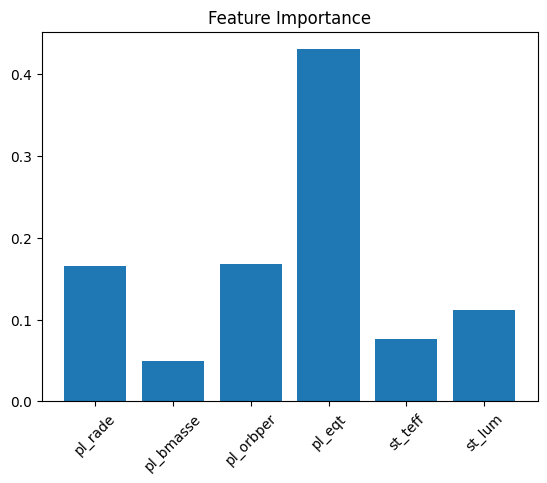

In [15]:
importances = rf.feature_importances_

plt.figure()
plt.bar(X.columns, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()


In [16]:
joblib.dump(rf, "habitability_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']